# Example of KiLCA interface in python
The following is a simple example to demonstrate some early features of the KiLCA interface in python. The example investigates the ratio of the radial magnetic field perturbation with plasma response over the same quantity without the plasma response, i.e. vacuum. This is done for multiple poloidal mode numbers and the toroidal mode number $n=2$.
For the input, profiles of the ASDEX Upgrade shot 33353 at time 2.9s are being used.

We start with importing the relevant modules and declaring path variables.

In [22]:
import os
import sys
kil_in_path = '../' # change path here accordingly. Should point to directory containing KiLCA_interface.py
sys.path.append(kil_in_path)
from KiLCA_interface import KiLCA_interface
from KiLCA_postprocessor import KiLCA_postprocessor
import numpy as np
import matplotlib.pyplot as plt

runpath = './runpath_example/'
prof_path = runpath + 'profiles/'
if not os.path.isdir(prof_path):
    os.makedirs(prof_path)

Next, we use the KiLCA interface to perform the FLRE and the vacuum runs for multiple poloidal mode numbers m. Also, the determined ratios of radial magnetic field components are plotted together with lines indicating the radius of the rational surfaces for the respective mode numbers. Apart from that, also the separatrix and the wall are indicated in the plot. As x-variable the normalized radius $r/a$ is used, where $a$ is the plasma radius, i.e. the effective radius of the separatrix.

Machine setting: AUG
Single RMP mode
The KiLCA run took 0.9681768417358398s
Output:

KiLCA interface was parsed
    shot      : 33353
    time slice: 2900
    run path  : ./runpath/vacuum/
    run type  : vacuum
    machine   : AUG
available modes:
    m = 4    n = 2
    m = 5    n = 2
    m = 6    n = 2
    m = 7    n = 2
    m = 8    n = 2
Machine setting: AUG
Single RMP mode
The KiLCA run took 2.214437484741211s
Output:

KiLCA interface was parsed
    shot      : 33353
    time slice: 2900
    run path  : ./runpath/flre/
    run type  : flre
    machine   : AUG
available modes:
    m = 4    n = 2
    m = 5    n = 2
    m = 6    n = 2
    m = 7    n = 2
    m = 8    n = 2
Machine setting: AUG
Single RMP mode
The KiLCA run took 1.0495891571044922s
Output:

KiLCA interface was parsed
    shot      : 33353
    time slice: 2900
    run path  : ./runpath/vacuum/
    run type  : vacuum
    machine   : AUG
available modes:
    m = 4    n = 2
    m = 5    n = 2
    m = 6    n = 2
    m = 7  

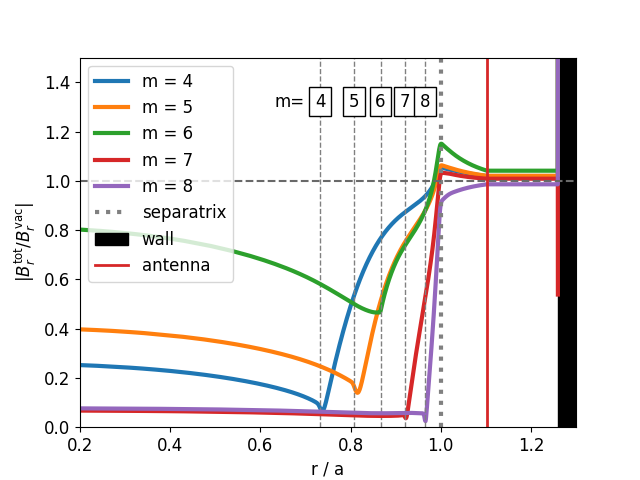

In [21]:
%matplotlib widget

a  = 63.5 # plasma radius

m_modes = [4,5,6,7,8]

q_prof = np.loadtxt(prof_path + 'q.dat')

plt.rc('font', size=12)
fig = plt.figure()
for m in m_modes:
    run_type = 'vacuum'
    kil_in = KiLCA_interface(33353, 2900, runpath, run_type)
    #kil_in.create_parabolic_profiles_from_res_surf(prof_path, q0, n0, Te0, Ti0, Vz0, Er0, Vth0, m_mode, n_mode, rmin, rmax, num, a)
    kil_in.set_modes(m,n_mode)
    kil_in.antenna.data['flab'] = [1.0, 0.0]
    kil_in.write()
    kil_in.run()
    kil_post_vac = KiLCA_postprocessor(kil_in)

    kil_post_vac.read_EB(m=m,n=n_mode)
    kil_post_vac.EB_to_fields(kil_post_vac.EBdat, m=m, n=n_mode)
    r_vac = kil_post_vac.r
    Br_vac = kil_post_vac.Br_real + 1j * kil_post_vac.Br_imag

    run_type = 'flre'
    kil_in = KiLCA_interface(33353, 2900, runpath, run_type)
    kil_in.set_modes(m,n_mode)
    kil_in.antenna.data['flab'] = [1.0, 0.0]
    kil_in.write()
    kil_in.run()
    kil_post = KiLCA_postprocessor(kil_in)

    kil_post.read_EB(m=m,n=n_mode)
    kil_post.EB_to_fields(kil_post.EBdat, m=m, n=n_mode)
    r_flre = kil_post.r
    Br_flre = kil_post.Br_real + 1j * kil_post.Br_imag

    plt.plot(r_vac/a, np.abs(np.interp(r_vac, r_flre, Br_flre) / Br_vac), lw=3, label=f'm = {m}')

    rres = np.interp(m/n_mode, np.abs(q_prof[:,1]), q_prof[:,0])
    plt.axvline(rres/a, ls='--', c='grey', lw=1)
    plt.text(rres/a, 1.3, f'{m}', bbox=dict(facecolor='w', edgecolor='k'), ha='center')
    if m==4:
        plt.text(rres/a - 0.1, 1.3, f'm=')

plt.ylim(0, 1.5e0)
xlim = [.2, 1.3]
plt.xlim(xlim)

plt.axvline(1, ls=':', c='grey', label='separatrix', lw=3)
plt.axhline(1.0, ls='--', c='dimgrey')
#plt.axvline(80/a, ls='-', c='k', lw=5, label='wall')
plt.axvspan(80/a, xlim[1], color='k', label='wall')
plt.axvline(70/a, ls='-', c='tab:red', lw=2, label='antenna')
plt.xlabel(r'r / a')
plt.ylabel(r'$|B_r^{\rm tot} / B_r^{\rm vac}|$')
plt.legend(loc='upper left')
plt.show()

The figure shows that the smallest shielding is for the poloidal mode number $m=6$ since in this case the ratio of radial magnetic field components is maximal at the rational surface.